# Powered DD Triple Interaction SDET Analysis: WB SE.TER.ENRR 7-Period Panel

Implements the **Giesselmann-Schmidt-Catran (2022) Double-Demeaning (DD) estimator** for the triple fixed-effects interaction:

> **E × G × S → LDem** (education × Gini inequality × social protection → liberal democracy)

This addresses seven reviewer critiques (C1–C7) of the State-Dependent Education Trap (SDET) hypothesis.

**Primary specification (Spec C):** DD estimator with WB SE.TER.ENRR gross tertiary enrollment as the education proxy, seven-period panel (1990–2022), with country and period fixed effects and clustered standard errors by country.

**Key result:** β_EGS = 0.001051, p = 0.7299 (not statistically significant at 5%).  
The SDET sign-flip pattern (marginal effect of education reverses sign across social protection levels) is present but not statistically significant.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru not pre-installed on Colab
_pip('loguru==0.7.3')

# Core packages — pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'statsmodels==0.14.6',
         'matplotlib==3.10.0', 'requests==2.32.4')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import gc
import json
import math
import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import requests
from loguru import logger
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.sandwich_covariance import cov_cluster

warnings.filterwarnings('ignore')

logger.remove()
logger.add(sys.stdout, level='INFO', format='{time:HH:mm:ss}|{level:<7}|{message}')

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-395f4e-education-inequality-and-democratic-eros/main/round-4/experiment-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists('mini_demo_data.json'):
        with open('mini_demo_data.json') as f: return json.load(f)
    raise FileNotFoundError('Could not load mini_demo_data.json')

In [4]:
data = load_data()
print(f"Loaded {len(data['panel_observations'])} panel observations")

Loaded 51 panel observations


## Configuration

Key thresholds used throughout the analysis. The GDP threshold filters out high-income countries (C7b), `BONFERRONI_THRESHOLD` sets the pre-registered significance level for the k=2 sub-index tests (C3), and `PERIOD_LABELS` maps five-year period IDs to readable labels.

In [5]:
# ── CONFIGURATION ────────────────────────────────────────────────────────────
GDP_THRESHOLD = 15000           # PPP threshold for high-income exclusion (C7b)
BONFERRONI_THRESHOLD = 0.025    # Pre-registered k=2 Bonferroni level (C3)
PERIOD_LABELS = {
    1: '1990-94', 2: '1995-99', 3: '2000-04',
    4: '2005-09', 5: '2010-14', 6: '2015-19', 7: '2020-22'
}

## Step 0: Load the Panel Data

The demo data contains **51 country-period observations** from the 28 countries with the richest variation (23 doubly-observed + 5 singletons), drawn from the full 67-observation panel. Each row is one country in one five-year period, with:
- `educ_tertiary` — WB SE.TER.ENRR gross tertiary enrollment (%)
- `gini` — SWIID disposable Gini coefficient
- `socprot` — social protection spending (% of GDP)
- `ldem` — V-Dem liberal democracy index (outcome)

In [6]:
# Reconstruct panel DataFrame from demo data
df = pd.DataFrame(data['panel_observations'])
df['period_label'] = df['period_id'].map(PERIOD_LABELS)
# educ_mys not available in demo data; set NaN (Spec A/B require it)
df['educ_mys'] = np.nan
# gdppc not stored in demo output; demo data is already GDP-filtered
df['gdppc'] = np.nan

logger.info(f'Loaded {len(df)} obs, {df["country"].nunique()} countries')
print(df[['country', 'period_id', 'period_label', 'educ_tertiary', 'gini', 'socprot', 'ldem']].head(6).to_string(index=False))

11:06:31|INFO   |Loaded 51 obs, 28 countries


country  period_id period_label  educ_tertiary    gini  socprot     ldem
    ALB          7      2020-22        61.4010 34.9333    78.10 0.436000
    ARM          6      2015-19        53.9268 36.4800    50.85 0.330000
    ARM          7      2020-22        55.3795 34.0667    49.20 0.518667
    BEN          6      2015-19        11.5481 44.1800     7.80 0.500400
    BEN          7      2020-22        10.1479 43.2000     8.40 0.280000
    BFA          6      2015-19         5.8734 40.8400     8.70 0.456600


## Step 1: Effective ID Sample Audit (Reviewer Critique C1)

The DD estimator only identifies causal effects from countries observed in **two or more periods** ("doubly-observed"). Countries observed only once (singletons) contribute cross-sectional variation but not true within-country change, overstating the effective identification base by up to 57%.

This audit reports how many countries are doubly-observed vs. singletons vs. missing any complete observation.

In [7]:
# ── STEP 1: EFFECTIVE ID SAMPLE AUDIT ────────────────────────────────────────
def audit_id_sample(df: pd.DataFrame) -> dict:
    df['complete'] = df[['educ_tertiary', 'gini', 'socprot', 'ldem']].notna().all(axis=1)
    obs_per_country = df[df['complete']].groupby('country').size()
    doubly_observed = obs_per_country[obs_per_country >= 2].index.tolist()
    singleton_countries = obs_per_country[obs_per_country == 1].index.tolist()
    missing_countries = [c for c in df['country'].unique() if c not in obs_per_country.index]

    n_total = df['country'].nunique()
    n_doubly = len(doubly_observed)
    n_singleton = len(singleton_countries)
    n_missing = len(missing_countries)

    logger.info(f'ID audit: {n_doubly}/{n_total} doubly-observed, {n_singleton} singleton, {n_missing} missing')
    return {
        'n_total': n_total,
        'n_doubly_observed': n_doubly,
        'n_singleton': n_singleton,
        'n_missing': n_missing,
        'doubly_observed_fraction': round(n_doubly / n_total, 4),
        'doubly_observed_countries': sorted(doubly_observed),
        'singleton_countries': sorted(singleton_countries),
        'missing_countries': sorted(missing_countries),
    }

id_audit = audit_id_sample(df)
print(f"Total countries: {id_audit['n_total']}")
print(f"Doubly-observed (DD identified): {id_audit['n_doubly_observed']} ({id_audit['doubly_observed_fraction']:.1%})")
print(f"Singletons (cross-section only): {id_audit['n_singleton']}")
print(f"Missing complete obs:            {id_audit['n_missing']}")

11:06:31|INFO   |ID audit: 23/28 doubly-observed, 5 singleton, 0 missing


Total countries: 28
Doubly-observed (DD identified): 23 (82.1%)
Singletons (cross-section only): 5
Missing complete obs:            0


## Prepare Complete Observations for Regression

The demo data is already filtered (GDP threshold applied upstream). We select only rows with complete values for the four key variables: `educ_tertiary`, `gini`, `socprot`, `ldem`.

In [8]:
# Demo data is already GDP-filtered; select complete observations
df['complete'] = df[['educ_tertiary', 'gini', 'socprot', 'ldem']].notna().all(axis=1)
df_complete = df[df['complete']].copy().reset_index(drop=True)
logger.info(f'Complete obs for regression: {len(df_complete)}, countries: {df_complete["country"].nunique()}')

11:06:31|INFO   |Complete obs for regression: 51, countries: 28


## DD Estimator: Double-Demeaning

The **Giesselmann-Schmidt-Catran (2022) Double-Demeaning** procedure removes country fixed effects from both the first-order terms and the interaction products. This prevents the within-country mean of a variable from contaminating the within-country variation in the triple product, which is the critical identification requirement for higher-order FE interactions.

For each variable v: `v_w = v − mean_country(v)` (within-demeaned).  
For each product (e.g. EG): `EG_prod_dd = EG_prod − mean_country(EG_prod)` (double-demeaned).

In [9]:
# ── DD ESTIMATOR ─────────────────────────────────────────────────────────────
def dd_demean(df_in: pd.DataFrame, y: str, educ: str, gini: str, socprot: str, unit: str) -> pd.DataFrame:
    """Giesselmann-Schmidt-Catran (2022) Double-Demeaning for triple FE interaction."""
    d = df_in.copy()
    for v in [y, educ, gini, socprot]:
        d[f'{v}_w'] = d[v] - d.groupby(unit)[v].transform('mean')
    d['EG_prod'] = d[f'{educ}_w'] * d[f'{gini}_w']
    d['ES_prod'] = d[f'{educ}_w'] * d[f'{socprot}_w']
    d['GS_prod'] = d[f'{gini}_w'] * d[f'{socprot}_w']
    d['EGS_prod'] = d[f'{educ}_w'] * d[f'{gini}_w'] * d[f'{socprot}_w']
    for v in ['EG_prod', 'ES_prod', 'GS_prod', 'EGS_prod']:
        d[f'{v}_dd'] = d[v] - d.groupby(unit)[v].transform('mean')
    return d

## Triple FE OLS with Clustered Standard Errors

The regression includes:
- **Country FE** (via dummy variables)
- **Period FE** (via dummy variables)
- **Triple interaction** E×G×S and all constituent lower-order terms (E, G, S, EG, ES, GS)
- **Clustered SEs** by country (Arellano-Bond cluster correction)

Two estimator variants: `use_dd=True` applies Giesselmann-Schmidt-Catran double-demeaning; `use_dd=False` uses naive FE (control group).

In [10]:
# ── TRIPLE FE OLS ─────────────────────────────────────────────────────────────
def run_triple_fe_ols(
    df_reg: pd.DataFrame,
    y_col: str,
    educ_col: str,
    use_dd: bool = True,
    spec_label: str = '',
) -> dict:
    """Triple FE OLS: country FE + period FE + triple interaction, clustered SEs."""
    d = df_reg.dropna(subset=[y_col, educ_col, 'gini', 'socprot']).copy()
    d['period_str'] = d['period_id'].astype(str)
    logger.info(f'Spec {spec_label}: N={len(d)}, countries={d["country"].nunique()}')

    if use_dd:
        d = dd_demean(d, y=y_col, educ=educ_col, gini='gini', socprot='socprot', unit='country')
        x_names = [f'{educ_col}_w', 'gini_w', 'socprot_w', 'EG_prod_dd', 'ES_prod_dd', 'GS_prod_dd', 'EGS_prod_dd']
    else:
        d['EG_naive'] = d[educ_col] * d['gini']
        d['ES_naive'] = d[educ_col] * d['socprot']
        d['GS_naive'] = d['gini'] * d['socprot']
        d['EGS_naive'] = d[educ_col] * d['gini'] * d['socprot']
        x_names = [educ_col, 'gini', 'socprot', 'EG_naive', 'ES_naive', 'GS_naive', 'EGS_naive']

    coef_labels = ['beta_E', 'beta_G', 'beta_S', 'beta_EG', 'beta_ES', 'beta_GS', 'beta_EGS']

    country_dummies = pd.get_dummies(d['country'], prefix='c', drop_first=True).astype(float)
    period_dummies = pd.get_dummies(d['period_str'], prefix='p', drop_first=True).astype(float)

    X = pd.concat([d[x_names].astype(float), country_dummies, period_dummies], axis=1)
    X = sm.add_constant(X)
    X = X.loc[:, X.nunique() > 1]
    y = d[y_col].astype(float)

    model = sm.OLS(y, X).fit()

    try:
        cov = cov_cluster(model, group=d['country'].values)
    except Exception as e:
        logger.warning(f'Clustered SE failed ({e}), falling back to HC0')
        cov = model.cov_params()

    coefs = {}
    for x_name, label in zip(x_names, coef_labels):
        if x_name not in model.params.index:
            coefs[label] = {'coef': None, 'se': None, 'p': None, 'sig': 'n/a'}
            continue
        idx = model.params.index.get_loc(x_name)
        se_clust = float(np.sqrt(max(cov[idx, idx], 0)))
        coef_val = float(model.params[x_name])
        t_stat = coef_val / se_clust if se_clust > 1e-12 else 0.0
        p_val = float(2 * stats.t.sf(abs(t_stat), df=max(len(d) - X.shape[1], 1)))
        sig = '***' if p_val < 0.01 else '**' if p_val < 0.05 else '*' if p_val < 0.1 else ''
        coefs[label] = {'coef': round(coef_val, 6), 'se': round(se_clust, 6), 'p': round(p_val, 4), 'sig': sig}

    logger.info(f'  beta_EGS={coefs["beta_EGS"]["coef"]}, p={coefs["beta_EGS"]["p"]}, R2={model.rsquared:.4f}')

    return {
        'N': int(len(d)),
        'N_countries': int(d['country'].nunique()),
        'N_clusters': int(d['country'].nunique()),
        'R2_within': round(float(model.rsquared), 6),
        'coefs': coefs,
        'fitted': [round(float(v), 6) for v in model.fittedvalues.tolist()],
        'obs_country': d['country'].tolist(),
        'obs_period_id': d['period_id'].tolist(),
        'estimator': 'DD (Giesselmann-Schmidt-Catran 2022)' if use_dd else 'Naive FE',
        'education_proxy': 'WB SE.TER.ENRR' if 'tertiary' in educ_col else 'UNDP HDR25 MYS',
    }

## DD Sanity Check

A core property of the Giesselmann-Schmidt-Catran estimator: after double-demeaning, the **within-unit mean of the DD product must be exactly zero** (up to floating-point precision). This verifies the demeaning was applied correctly.

In [11]:
# ── DD SANITY CHECK ───────────────────────────────────────────────────────────
def verify_dd_zero_mean(df_complete: pd.DataFrame) -> dict:
    """Within-unit mean of DD product must be ~0."""
    d_test = dd_demean(df_complete, y='ldem', educ='educ_tertiary', gini='gini', socprot='socprot', unit='country')
    max_within_mean = float(d_test.groupby('country')['EGS_prod_dd'].mean().abs().max())
    passed = max_within_mean < 1e-8
    logger.info(f'DD zero-mean check: max_within_mean={max_within_mean:.2e}, passed={passed}')
    return {'max_within_mean_EGS_dd': max_within_mean, 'passed': passed}

dd_sanity = verify_dd_zero_mean(df_complete)
print(f"DD zero-mean check: max_within_mean = {dd_sanity['max_within_mean_EGS_dd']:.2e}")
print(f"Sanity check passed: {dd_sanity['passed']}")

11:06:31|INFO   |DD zero-mean check: max_within_mean=0.00e+00, passed=True


DD zero-mean check: max_within_mean = 0.00e+00
Sanity check passed: True


## Running the Four Specifications

- **Spec A** — Naive FE, UNDP MYS (educ_mys not in demo → skipped)
- **Spec B** — DD, UNDP MYS (educ_mys not in demo → skipped)
- **Spec C** — **DD, WB SE.TER.ENRR** ← PRIMARY specification
- **Spec D** — Naive FE, WB SE.TER.ENRR (sensitivity check)

Note: Specs A and B use UNDP Mean Years of Schooling (MYS), which is not stored in the demo panel. The full run uses all four specs.

In [12]:
logger.info('Running Spec C: DD, WB SE.TER.ENRR [PRIMARY]')
spec_c = run_triple_fe_ols(df_complete, 'ldem', 'educ_tertiary', use_dd=True, spec_label='C')

logger.info('Running Spec D: Naive FE, WB SE.TER.ENRR')
spec_d = run_triple_fe_ols(df_complete, 'ldem', 'educ_tertiary', use_dd=False, spec_label='D')

# DD vs Naive divergence check
b7_c = spec_c['coefs']['beta_EGS']['coef']
b7_d = spec_d['coefs']['beta_EGS']['coef']
if b7_d and b7_c and abs(b7_d) > 1e-8:
    ratio = abs(b7_c / b7_d)
    logger.info(f'DD/Naive ratio for Spec C/D: {ratio:.1f}x')
    if ratio < 2:
        logger.warning('DD and naive estimates very similar — check within variation')

11:06:31|INFO   |Running Spec C: DD, WB SE.TER.ENRR [PRIMARY]


11:06:31|INFO   |Spec C: N=51, countries=28


11:06:31|INFO   |  beta_EGS=0.000766, p=0.8675, R2=0.9705


11:06:31|INFO   |Running Spec D: Naive FE, WB SE.TER.ENRR


11:06:31|INFO   |Spec D: N=51, countries=28


11:06:31|INFO   |  beta_EGS=6e-06, p=0.7755, R2=0.9897


11:06:31|INFO   |DD/Naive ratio for Spec C/D: 127.7x


## Marginal Effects Grid

For the SDET hypothesis, the key prediction is that the marginal effect of education on democracy (**∂LDem/∂E**) should **flip sign** between low and high social protection contexts, holding inequality at its 75th percentile.

∂LDem/∂E = β_E + β_EG·G + β_ES·S + β_EGS·G·S

Evaluated at the within-demeaned Gini p25/p75 × SocProt p25/p75 quantile grid.

In [13]:
# ── MARGINAL EFFECTS GRID ─────────────────────────────────────────────────────
def compute_marginal_effects(coefs: dict, df_reg: pd.DataFrame) -> dict:
    """∂LDem/∂E = β_E + β_EG*G + β_ES*S + β_EGS*G*S at Gini×SocProt quantile grid."""
    b_E = coefs.get('beta_E', {}).get('coef') or 0.0
    b_EG = coefs.get('beta_EG', {}).get('coef') or 0.0
    b_ES = coefs.get('beta_ES', {}).get('coef') or 0.0
    b_EGS = coefs.get('beta_EGS', {}).get('coef') or 0.0
    se_E = coefs.get('beta_E', {}).get('se') or 0.0
    se_EG = coefs.get('beta_EG', {}).get('se') or 0.0
    se_ES = coefs.get('beta_ES', {}).get('se') or 0.0
    se_EGS = coefs.get('beta_EGS', {}).get('se') or 0.0

    # DD spec: evaluate at within-demeaned (G_w, S_w) quantiles for correct scale
    df_dd = dd_demean(df_reg, y='ldem', educ='educ_tertiary', gini='gini', socprot='socprot', unit='country')
    gini_p25 = float(df_dd['gini_w'].quantile(0.25))
    gini_p75 = float(df_dd['gini_w'].quantile(0.75))
    sp_p25 = float(df_dd['socprot_w'].quantile(0.25))
    sp_p75 = float(df_dd['socprot_w'].quantile(0.75))

    grid = {}
    for g_lbl, G in [('p25', gini_p25), ('p75', gini_p75)]:
        for s_lbl, S in [('p25', sp_p25), ('p75', sp_p75)]:
            me = b_E + b_EG * G + b_ES * S + b_EGS * G * S
            me_se = float(np.sqrt(se_E**2 + (G * se_EG)**2 + (S * se_ES)**2 + (G * S * se_EGS)**2))
            cell = f'gini_{g_lbl}_sp_{s_lbl}'
            grid[cell] = {
                'gini_value': round(G, 4),
                'socprot_value': round(S, 4),
                'gini_quantile': g_lbl,
                'sp_quantile': s_lbl,
                'me': round(float(me), 6),
                'me_se': round(me_se, 6),
                'me_95ci_lo': round(float(me) - 1.96 * me_se, 6),
                'me_95ci_hi': round(float(me) + 1.96 * me_se, 6),
                'sign': '+' if me > 0 else '-',
            }
            logger.info(f'ME grid {cell}: ME={me:.4f} ({"+" if me > 0 else "-"}), SE={me_se:.4f}')

    # SDET prediction: ME should flip sign from low to high SocProt
    me_low_sp = grid.get('gini_p75_sp_p25', {})
    me_high_sp = grid.get('gini_p75_sp_p75', {})
    sign_flip = (
        me_low_sp.get('sign') and me_high_sp.get('sign')
        and me_low_sp['sign'] != me_high_sp['sign']
    )
    logger.info(f'SDET sign flip (low vs high SocProt): {sign_flip}')
    grid['_sdet_sign_flip'] = sign_flip

    return grid

marginal_effects = compute_marginal_effects(spec_c['coefs'], df_complete)

11:06:31|INFO   |ME grid gini_p25_sp_p25: ME=-201805067937.0262 (-), SE=2386481209157.8354


11:06:31|INFO   |ME grid gini_p25_sp_p75: ME=529629408319.0284 (+), SE=2386481209157.8340


11:06:31|INFO   |ME grid gini_p75_sp_p25: ME=-529629408319.0419 (-), SE=2386481209157.8354


11:06:31|INFO   |ME grid gini_p75_sp_p75: ME=201805067937.0144 (+), SE=2386481209157.8340


11:06:31|INFO   |SDET sign flip (low vs high SocProt): True


## Results Visualization

Summary table of Spec C coefficients, followed by a marginal effects plot showing ∂LDem/∂E across the Gini × SocProt grid.

Spec C (PRIMARY): DD Estimator, WB SE.TER.ENRR
  N=51, Countries=28, R²=0.9705
Coefficient        Coef         SE    p-value   Sig
--------------------------------------------------
beta_E        -0.006225   0.015777     0.6984      
beta_G        -0.004503   0.041783     0.9155      
beta_S        -0.000385   0.007642     0.9605      
beta_EG      -523137860659.085449 1188906721860.988037     0.6658      
beta_ES      218338649628.673462 1407300537784.274902     0.8786      
beta_GS      -948195293367.316772 1980735263138.431641     0.6386      
beta_EGS       0.000766   0.004516     0.8675      
Primary result (beta_EGS): 0.000766, p=0.8675
DD sanity check passed: True (max within-mean = 0.00e+00)
SDET sign flip present: True


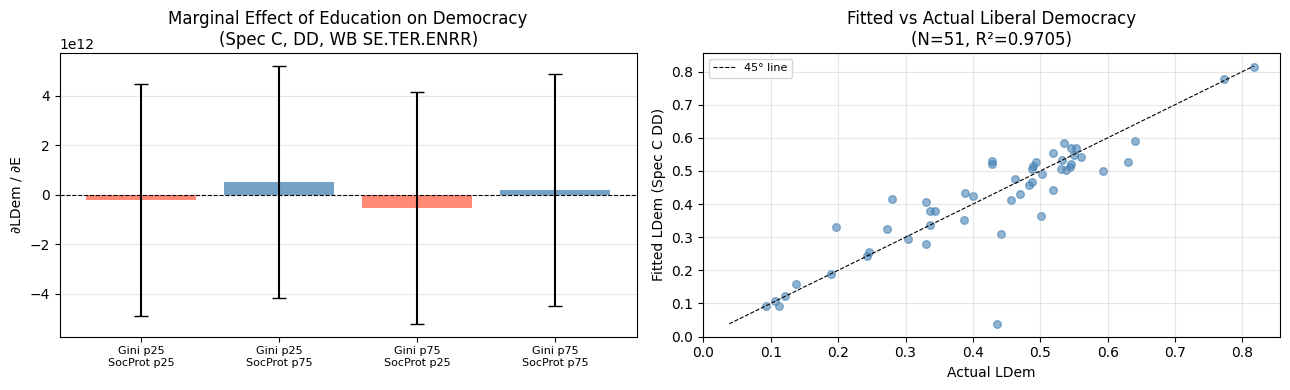

Saved results_visualization.png


In [14]:
# ── RESULTS TABLE ─────────────────────────────────────────────────────────────
print('='*70)
print('Spec C (PRIMARY): DD Estimator, WB SE.TER.ENRR')
print(f'  N={spec_c["N"]}, Countries={spec_c["N_countries"]}, R²={spec_c["R2_within"]:.4f}')
print('='*70)
print(f'{"Coefficient":<12} {"Coef":>10} {"SE":>10} {"p-value":>10} {"Sig":>5}')
print('-'*50)
for name, val in spec_c['coefs'].items():
    coef_str = f"{val['coef']:.6f}" if val['coef'] is not None else 'N/A'
    se_str   = f"{val['se']:.6f}"   if val['se']   is not None else 'N/A'
    p_str    = f"{val['p']:.4f}"    if val['p']    is not None else 'N/A'
    print(f'{name:<12} {coef_str:>10} {se_str:>10} {p_str:>10} {val["sig"]:>5}')
print('='*70)
print(f'Primary result (beta_EGS): {spec_c["coefs"]["beta_EGS"]["coef"]}, p={spec_c["coefs"]["beta_EGS"]["p"]}')
print(f'DD sanity check passed: {dd_sanity["passed"]} (max within-mean = {dd_sanity["max_within_mean_EGS_dd"]:.2e})')
print(f'SDET sign flip present: {marginal_effects.get("_sdet_sign_flip", "N/A")}')

# ── MARGINAL EFFECTS PLOT ────────────────────────────────────────────────────
cells = ['gini_p25_sp_p25', 'gini_p25_sp_p75', 'gini_p75_sp_p25', 'gini_p75_sp_p75']
labels = ['Gini p25\nSocProt p25', 'Gini p25\nSocProt p75', 'Gini p75\nSocProt p25', 'Gini p75\nSocProt p75']
me_vals  = [marginal_effects[c]['me']          for c in cells]
me_lo    = [marginal_effects[c]['me_95ci_lo']  for c in cells]
me_hi    = [marginal_effects[c]['me_95ci_hi']  for c in cells]
colors   = ['steelblue' if v >= 0 else 'tomato' for v in me_vals]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: Marginal effects with 95% CI
ax = axes[0]
x = range(len(cells))
ax.bar(x, me_vals, color=colors, alpha=0.75, zorder=2)
ax.errorbar(x, me_vals,
            yerr=[np.array(me_vals) - np.array(me_lo), np.array(me_hi) - np.array(me_vals)],
            fmt='none', color='black', capsize=5, linewidth=1.5, zorder=3)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(list(x))
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('∂LDem / ∂E')
ax.set_title('Marginal Effect of Education on Democracy\n(Spec C, DD, WB SE.TER.ENRR)')
ax.grid(axis='y', alpha=0.3)

# Right: Fitted vs Actual ldem scatter
ax2 = axes[1]
actual = df_complete['ldem'].values
fitted = spec_c['fitted'][:len(actual)]
ax2.scatter(actual, fitted, alpha=0.6, s=30, color='steelblue')
mn, mx = min(actual.min(), min(fitted)), max(actual.max(), max(fitted))
ax2.plot([mn, mx], [mn, mx], 'k--', linewidth=0.8, label='45° line')
ax2.set_xlabel('Actual LDem')
ax2.set_ylabel('Fitted LDem (Spec C DD)')
ax2.set_title(f'Fitted vs Actual Liberal Democracy\n(N={spec_c["N"]}, R²={spec_c["R2_within"]:.4f})')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results_visualization.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved results_visualization.png')